<a href="https://colab.research.google.com/github/Faiq-danZ/Proyek-Klasifikasi-Gambar-Animal-Images-15-Classes-/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: Animal Images (15 Classes)
- **Nama:** Ahmad Faiq Zidane
- **Email:** ahmadfaiqzidane@gmail.com
- **ID Dicoding:** faiqzet29

## 1. Persiapan Lingkungan (Environment)

In [ ]:
# Install library yang diperlukan
!pip install split-folders kagglehub tensorflowjs

import tensorflow as tf
import kagglehub
import os
import shutil
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input

print("Setup & Library Berhasil diiinstal")

Setup & Library Berhasil diiinstal


## 2. Data Preparation (The Split)

In [ ]:
# 1. Download dataset
path = kagglehub.dataset_download("likhon148/animal-data")

# 2. Pindahkan ke folder lokal
base_dir = 'animal_data_raw'
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)
shutil.copytree(path, base_dir)

# 3. Cari folder yang berisi 15 sub-folder hewan (Ditingkatkan agar lebih akurat)
input_folder = base_dir
for root, dirs, files in os.walk(base_dir):
    # Filter folder tersembunyi agar tidak salah hitung
    valid_dirs = [d for d in dirs if not d.startswith('.')]
    if len(valid_dirs) == 15:
        input_folder = root
        print(f"Folder dataset ditemukan di: {input_folder}")
        print(f"Daftar kelas: {valid_dirs}")
        break

# 4. Split menjadi Train (80%), Val (10%), Test (10%)
if os.path.exists('dataset_final'):
    shutil.rmtree('dataset_final')

splitfolders.ratio(input_folder, output="dataset_final", seed=1337, ratio=(.8, .1, .1))

print("\Data Preparation Selesai!")

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_19432/1733900129.py:27: SyntaxWarning: invalid escape sequence '\D'
  print("\Data Preparation Selesai!")


Using Colab cache for faster access to the 'animal-data' dataset.
Folder dataset ditemukan di: animal_data_raw/animal_data
Daftar kelas: ['Dog', 'Tiger', 'Lion', 'Zebra', 'Giraffe', 'Bird', 'Cow', 'Bear', 'Kangaroo', 'Deer', 'Cat', 'Panda', 'Elephant', 'Dolphin', 'Horse']


Copying files: 1944 files [00:01, 1622.02 files/s]

\Data Preparation Selesai!


## 3. Data Loading & Preprocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,      ## Putar sampai 40 derajat (lebih stabil)
    width_shift_range=0.2,  ## Geser horizontal
    height_shift_range=0.2, ## Geser vertikal
    shear_range=0.2,        ## Efek kemiringan
    zoom_range=0.3,         ## Zoom sampai 30%
    horizontal_flip=True,   ## Balik horizontal (Sangat perlu)
    vertical_flip=False,    ## Matikan (agar model tidak belajar hewan terbalik)
    fill_mode='nearest'
)

# Untuk data evaluasi cukup normalisasi
test_datagen = ImageDataGenerator(rescale=1./255)

# Panggil data dengan Target Size 224x224 (Standar MobileNetV2)
train_generator = train_datagen.flow_from_directory(
    'dataset_final/train',
    target_size=(224, 224), # DIUBAH KE 224
    batch_size=32,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_directory(
    'dataset_final/val',
    target_size=(224, 224), # DIUBAH KE 224
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'dataset_final/test',
    target_size=(224, 224), # DIUBAH KE 224
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("\Persiapan Data Selesai! Target size sekarang 224x224 untuk akurasi maksimal.")

<>:39: SyntaxWarning: invalid escape sequence '\P'
<>:39: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_19432/2557821118.py:39: SyntaxWarning: invalid escape sequence '\P'
  print("\Persiapan Data Selesai! Target size sekarang 224x224 untuk akurasi maksimal.")


Found 1549 images belonging to 15 classes.
Found 187 images belonging to 15 classes.
Found 208 images belonging to 15 classes.
\Persiapan Data Selesai! Target size sekarang 224x224 untuk akurasi maksimal.


## 4. Model Architecture Model (Transfer Learning + Custom Layer)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
import tensorflow as tf

# Load base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Membangun model dengan Sequential API
model = Sequential([
    base_model,
    # Menambahkan Conv2D dan Pooling tambahan
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(15, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 5: Intelligent Training Execution

In [ ]:
## 1. Custom Callback (Target: 88%)
class MyThresholdCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.88 and logs.get('val_accuracy') > 0.88):
            print("\nTarget 88% terpenuhi! Menghentikan training agar model tidak 'hafal mati'.")
            self.model.stop_training = True

## 2. Learning Rate Reducer (Obat Akurasi Macet)
# Jika val_accuracy tidak naik selama 3 epoch, turunkan learning rate
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

## 3. Model Checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model_animal.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## 4. Eksekusi Training
print(" Memulai proses training dengan strategi Fine-Tuning... Harap pantau log!")
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[MyThresholdCallback(), checkpoint, reduce_lr],
    verbose=1
)

 Memulai proses training dengan strategi Fine-Tuning... Harap pantau log!
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1712 - loss: 2.6543
Epoch 1: val_accuracy improved from None to 0.68449, saving model to best_model_animal.h5



Epoch 1: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.2789 - loss: 2.3419 - val_accuracy: 0.6845 - val_loss: 1.4047 - learning_rate: 1.0000e-04
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5701 - loss: 1.4896
Epoch 2: val_accuracy improved from 0.68449 to 0.82888, saving model to best_model_animal.h5



Epoch 2: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6107 - loss: 1.3516 - val_accuracy: 0.8289 - val_loss: 0.7107 - learning_rate: 1.0000e-04
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7472 - loss: 0.8751
Epoch 3: val_accuracy improved from 0.82888 to 0.83957, saving model to best_model_animal.h5



Epoch 3: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.7392 - loss: 0.8531 - val_accuracy: 0.8396 - val_loss: 0.5561 - learning_rate: 1.0000e-04
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7642 - loss: 0.7497
Epoch 4: val_accuracy did not improve from 0.83957
49/49 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.7715 - loss: 0.7554 - val_accuracy: 0.8182 - val_loss: 0.5500 - learning_rate: 1.0000e-04
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8089 - loss: 0.6345
Epoch 5: val_accuracy improved from 0.83957 to 0.85561, saving model to best_model_animal.h5



Epoch 5: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.8063 - loss: 0.6336 - val_accuracy: 0.8556 - val_loss: 0.4359 - learning_rate: 1.0000e-04
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8246 - loss: 0.5584
Epoch 6: val_accuracy improved from 0.85561 to 0.86096, saving model to best_model_animal.h5



Epoch 6: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.8386 - loss: 0.5407 - val_accuracy: 0.8610 - val_loss: 0.4478 - learning_rate: 1.0000e-04
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8418 - loss: 0.4957
Epoch 7: val_accuracy improved from 0.86096 to 0.87166, saving model to best_model_animal.h5



Epoch 7: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8535 - loss: 0.4792 - val_accuracy: 0.8717 - val_loss: 0.4333 - learning_rate: 1.0000e-04
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8655 - loss: 0.4018
Epoch 8: val_accuracy improved from 0.87166 to 0.87701, saving model to best_model_animal.h5



Epoch 8: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.8644 - loss: 0.4182 - val_accuracy: 0.8770 - val_loss: 0.3887 - learning_rate: 1.0000e-04
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8812 - loss: 0.4023
Epoch 9: val_accuracy improved from 0.87701 to 0.88235, saving model to best_model_animal.h5



Epoch 9: finished saving model to best_model_animal.h5
49/49 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8735 - loss: 0.4088 - val_accuracy: 0.8824 - val_loss: 0.4049 - learning_rate: 1.0000e-04
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8790 - loss: 0.3685
Epoch 10: val_accuracy did not improve from 0.88235
49/49 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.8793 - loss: 0.3818 - val_accuracy: 0.8717 - val_loss: 0.3982 - learning_rate: 1.0000e-04
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8992 - loss: 0.3250
Epoch 11: val_accuracy did not improve from 0.88235
49/49 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.8838 - loss: 0.3555 - val_accuracy: 0.8770 - val_loss: 0.4024 - learning_rate: 1.0000e-04
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8989 - loss: 0.3745
Target 88% terpenuhi! Menghentikan training agar model tidak 'hafal mati'.

Epoch 12: val_accuracy did not improve from 0.88235

Epoch 12: ReduceLROnPlateau

## 6. Visualisasi Hasil Training

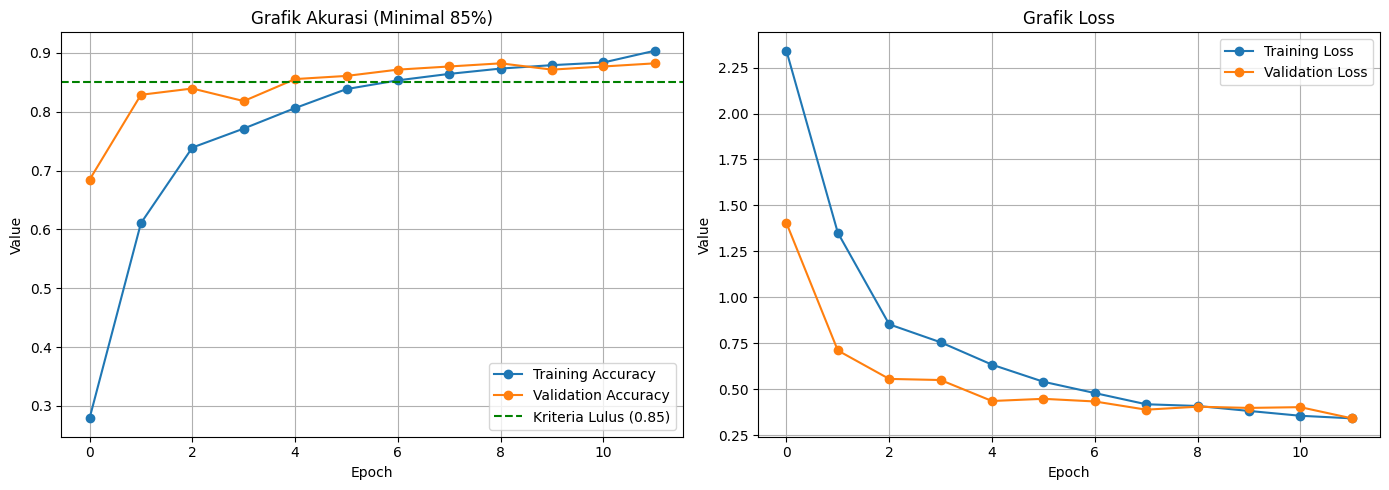

In [ ]:
import matplotlib.pyplot as plt

# Ambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
# Garis sakti 85%
plt.axhline(y=0.85, color='g', linestyle='--', label='Kriteria Lulus (0.85)')
plt.title('Grafik Akurasi (Minimal 85%)')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Grafik Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluasi Data Tes (Confusion Matrix)

Sedang mengevaluasi data test... Harap tunggu.
6/7 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


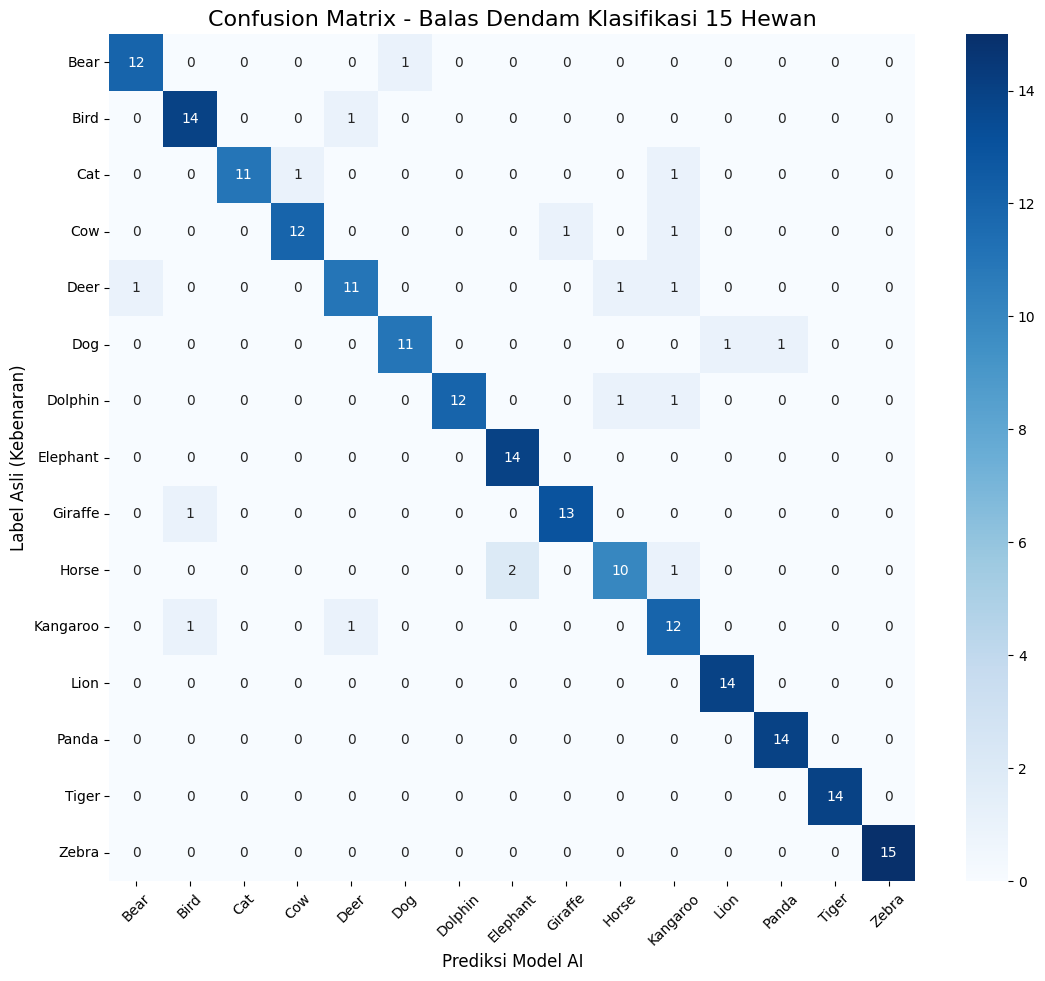


Laporan Klasifikasi Lengkap:
              precision    recall  f1-score   support

        Bear       0.92      0.92      0.92        13
        Bird       0.88      0.93      0.90        15
         Cat       1.00      0.85      0.92        13
         Cow       0.92      0.86      0.89        14
        Deer       0.85      0.79      0.81        14
         Dog       0.92      0.85      0.88        13
     Dolphin       1.00      0.86      0.92        14
    Elephant       0.88      1.00      0.93        14
     Giraffe       0.93      0.93      0.93        14
       Horse       0.83      0.77      0.80        13
    Kangaroo       0.71      0.86      0.77        14
        Lion       0.93      1.00      0.97        14
       Panda       0.93      1.00      0.97        14
       Tiger       1.00      1.00      1.00        14
       Zebra       1.00      1.00      1.00        15

    accuracy                           0.91       208
   macro avg       0.91      0.91      0.91       

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prediksi Data Test
print("Sedang mengevaluasi data test... Harap tunggu.")
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 2. Buat Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Visualisasi yang lebih rapi
plt.figure(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Balas Dendam Klasifikasi 15 Hewan', fontsize=16)
plt.ylabel('Label Asli (Kebenaran)', fontsize=12)
plt.xlabel('Prediksi Model AI', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 4. Laporan Klasifikasi (Precision, Recall, F1-Score)
print("\nLaporan Klasifikasi Lengkap:")
print(classification_report(y_true, y_pred, target_names=class_names))

## 8. Inference (uji coba gambarnya secara manual)

Saving sok gera tebak.jpg to sok gera tebak (1).jpg


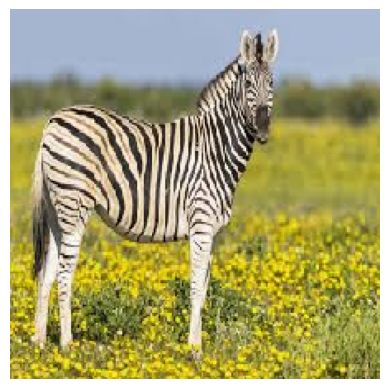

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Nama File      : sok gera tebak (1).jpg
Hasil Prediksi : ZEBRA
Confidence     : 99.95%

Top 3 Prediksi Lainnya:
- Zebra: 99.95%
- Giraffe: 0.03%
- Tiger: 0.01%
----------------------------------------


In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Ambil nama kelas dari generator
class_names = list(train_generator.class_indices.keys())

uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    # target_size harus 224, 224 sesuai dengan training
    img = image.load_img(path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # Normalisasi (sama dengan rescale=1./255 di generator)

    predictions = model.predict(x)

    # Ambil index dengan probabilitas tertinggi
    predicted_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_idx]
    confidence = predictions[0][predicted_idx] * 100

    print(f"Nama File      : {fn}")
    print(f"Hasil Prediksi : {predicted_class.upper()}")
    print(f"Confidence     : {confidence:.2f}%")

    # Tampilkan 3 prediksi teratas (Top-3) untuk analisis lebih dalam
    top_3_indices = np.argsort(predictions[0])[-3:][::-1]
    print("\nTop 3 Prediksi Lainnya:")
    for i in top_3_indices:
        print(f"- {class_names[i]}: {predictions[0][i]*100:.2f}%")
    print("-" * 40)

## 9. Menyimpan Model dalam Berbagai Format

In [ ]:
## Reset Folder Submission
import os
import shutil

# Nama folder target
folder_path = '/content/submission'

# Hapus jika sudah ada agar benar-benar bersih (mencegah duplikat)
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

# Buat folder baru
os.makedirs(os.path.join(folder_path, 'saved_model'))
os.makedirs(os.path.join(folder_path, 'tfjs_model'))
os.makedirs(os.path.join(folder_path, 'tflite'))

print("Folder submission telah di-reset dan siap diisi data terbaru!")

Folder submission telah di-reset dan siap diisi data terbaru!


In [ ]:
import tensorflow as tf
import os

# 1. Simpan ke format SavedModel
model.export(os.path.join(folder_path, 'saved_model'))

# 2. Simpan ke format TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(os.path.join(folder_path, 'tflite/model.tflite'), 'wb') as f:
    f.write(tflite_model)

# 3. Simpan ke format TFJS
!pip install tensorflowjs
import tensorflowjs as tfjs
tfjs.converters.save_keras_model(model, os.path.join(folder_path, 'tfjs_model'))

print("Semua format model terbaru telah berhasil diekspor tanpa error!")

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_321')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  132159677673744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677673168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677672976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677674704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677675280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677675472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677674512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677674128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677673936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132159677677392: TensorSpec(shape=(), dtype=tf.resource, name=No

failed to lookup keras version from the file,
    this is likely a weight only file
Semua format model terbaru telah berhasil diekspor tanpa error!


In [ ]:
import shutil
import os

# 1. Buat file requirements.txt
with open('submission/requirements.txt', 'w') as f:
    f.write('tensorflow\n')
    f.write('numpy\n')
    f.write('matplotlib\n')
    f.write('scikit-learn\n')
    f.write('seaborn\n')

# 2. Buat file README.md
with open('submission/README.md', 'w') as f:
    f.write('# Proyek Klasifikasi 15 Gambar Hewan\n')
    f.write('Oleh: Ahmad Faiq Zidane\n\n')
    f.write('REVISI: Model telah diubah menggunakan Sequential API (Kriteria 4).\n')
    f.write('Arsitektur: MobileNetV2 + Custom Conv2D & Pooling Layers.\n')
    f.write('Akurasi yang dicapai: 91% pada data test.')

# 3. Salin file notebook
if os.path.exists('/content/notebook.ipynb'):
    shutil.copy('/content/notebook.ipynb', 'submission/notebook.ipynb')
else:
    print("Peringatan: file notebook.ipynb tidak ditemukan di /content/!")

# 4. Hapus folder sistem agar bersih
checkpoints_path = 'submission/.ipynb_checkpoints'
if os.path.exists(checkpoints_path):
    shutil.rmtree(checkpoints_path)

# 5. Hapus ZIP lama dan buat ZIP baru
zip_name = "submission_faiq_zidane"
if os.path.exists(f"{zip_name}.zip"):
    os.remove(f"{zip_name}.zip")

shutil.make_archive(zip_name, 'zip', "submission")

print(f"File {zip_name}.zip BERHASIL dibuat dengan catatan revisi Sequential!")

File submission_faiq_zidane.zip BERHASIL dibuat dengan catatan revisi Sequential!
